# The Virtue of Complexity in Return Prediction

## Overview

This notebook replicates the findings from **Kelly, Malamud, and Zhou (2021)**: *"The Virtue of Complexity in Return Prediction"*.

### Key Insight

Contrary to conventional wisdom in finance, the paper demonstrates that **highly parameterized models can outperform simpler ones** in return prediction, even when the number of parameters (P) exceeds the number of observations (T). This challenges the traditional bias-variance tradeoff intuition.

### Methodology

The approach uses:
1. **Random Fourier Features (RFF)** to expand the feature space to high dimensions
2. **Ridge Regression** with optimal regularization to prevent overfitting
3. **Rolling-window backtesting** for out-of-sample evaluation

### Paper Reference

> Kelly, B., Malamud, S., & Zhou, K. (2021). *The Virtue of Complexity in Return Prediction*. Swiss Finance Institute Research Paper No. 21-90. [SSRN](https://ssrn.com/abstract=3984925)

### Code Structure

The implementation is modularized in the `src/` directory:
- [`rff.py`](../src/rff.py) - Random Fourier Features transformation
- [`backtest.py`](../src/backtest.py) - Ridge regression backtesting framework
- [`dataset.py`](../src/dataset.py) - Data loading and preprocessing

In [ ]:
import sys
print(sys.version)

3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 17.0.0 (clang-1700.6.3.2)]


In [6]:
pip install missingno


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Setup

In [7]:
%matplotlib inline

import sys
sys.path.insert(0, "..")  # Add parent directory to path for src imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
import itertools

from src import dataset, PLOTS_DIR, DATA_DIR, ensure_dirs_exist
from src.rff import RandomFourierFeatures

from src.config import (
    DEFAULT_TRAIN_WINDOW,
    GAMMA_VALUES,
    Z_VALUES_RANGE,
    STANDARDIZATION_BURN_IN,
    METRICS_CACHE_FILE,
)

from joblib import Parallel, delayed

# Ensure output directories exist
ensure_dirs_exist()

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 100

In [8]:
from src.backtest_LSTM import BacktestLSTM

## 1. Data Loading

We use the **Welch-Goyal (2008) dataset** of monthly equity premium predictors, which is the standard benchmark dataset for return prediction research.

### Features (14 predictors)

| Feature | Description |
|---------|-------------|
| `b/m` | Book-to-market ratio |
| `dp` | Dividend-price ratio (log) |
| `dy` | Dividend yield (log) |
| `ep` | Earnings-price ratio (log) |
| `de` | Dividend payout ratio (log) |
| `tms` | Term spread (long-term yield - T-bill) |
| `dfy` | Default yield spread (BAA - AAA) |
| `dfr` | Default return spread |
| `infl` | Inflation |
| `ltr` | Long-term return |
| `lty` | Long-term yield |
| `ntis` | Net equity expansion |
| `svar` | Stock variance |
| `tbl` | Treasury bill rate |

### Additional Data
- **NBER recession dates** for visualization of market timing performance

In [9]:
# Load data using the dataset module
COLUMNS = dataset.PREDICTOR_COLUMNS[:-1]  # Exclude 'returns' from features
nber = dataset.load_nber()
data, returns = dataset.load_data()

print(f"Data shape: {data.shape}")
print(f"Date range: {data.index.min()} to {data.index.max()}")
print(f"\nFeatures ({len(COLUMNS)}): {COLUMNS}")

Data shape: (1141, 15)
Date range: 1926-12-01 00:00:00 to 2021-12-01 00:00:00

Features (14): ['b/m', 'de', 'dfr', 'dfy', 'dp', 'dy', 'ep', 'infl', 'ltr', 'lty', 'ntis', 'svar', 'tbl', 'tms']


## 2. Data Exploration

Before modeling, we examine the data quality and feature relationships:

1. **Missing Data Pattern** - Visualize data completeness over time
2. **Feature Covariance** - Understand correlations between predictors

The heatmap reveals which predictors move together, helping us understand the information structure in our feature set.

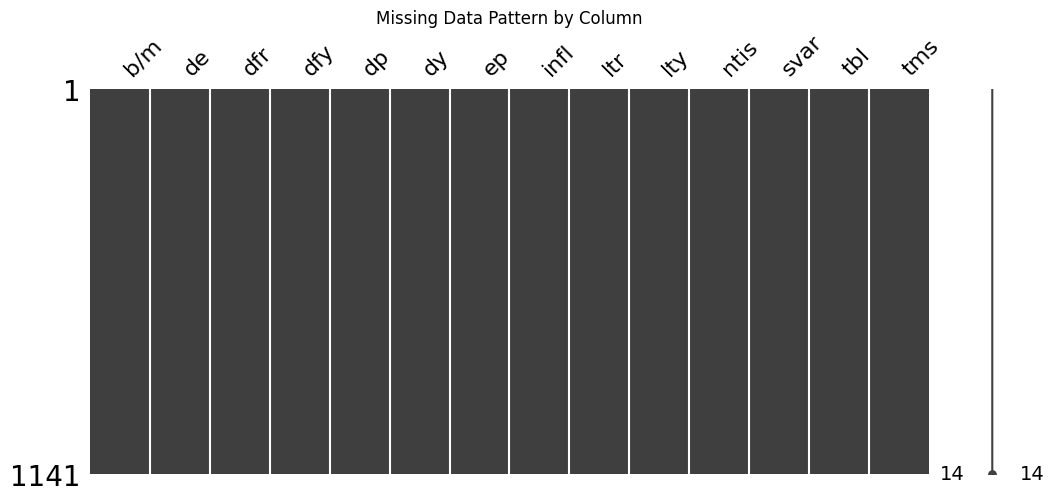

In [10]:
# Visualize missing data patterns
msno.matrix(data[COLUMNS], figsize=(12, 5))
plt.title("Missing Data Pattern by Column")
plt.savefig(PLOTS_DIR / "missing_pattern.jpg", bbox_inches='tight')
plt.show()

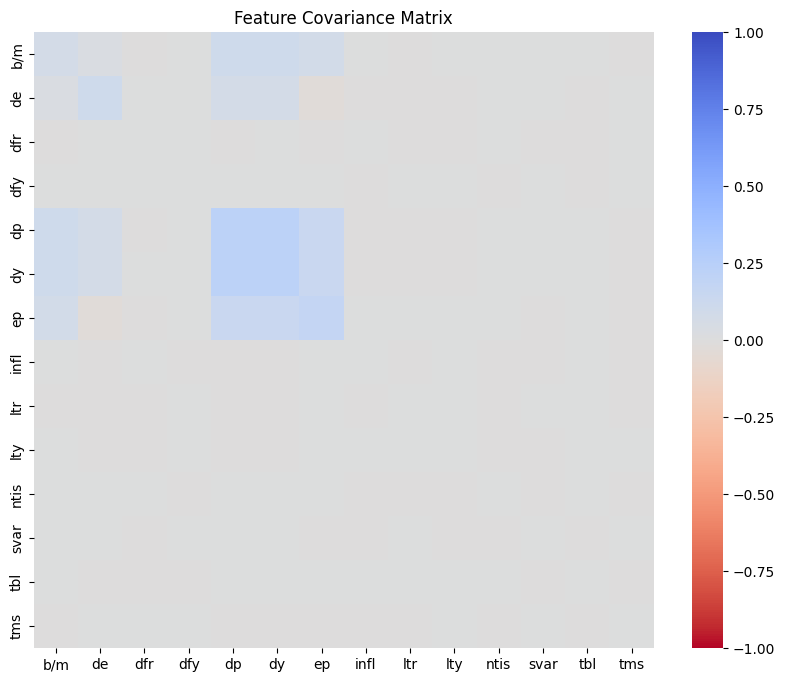

In [11]:
# Covariance matrix of features
plt.figure(figsize=(10, 8))
sns.heatmap(
    data[COLUMNS].cov(), 
    center=0, 
    vmin=-1, 
    vmax=1, 
    cmap=sns.color_palette("coolwarm_r", as_cmap=True),
    annot=False
)
plt.title("Feature Covariance Matrix")
plt.savefig(PLOTS_DIR / "covariance.jpg", bbox_inches='tight')
plt.show()

## 3. Data Standardization

From the paper:

> We volatility standardize returns and predictors using backward-looking standard deviations that preserve the out-of-sample nature of our forecasts. 

> Returns are standardized by their trailing 12-month return standard deviation (to capture their comparatively fast-moving conditional volatility), while predictors are standardized using an expanding window historical standard deviation (given the much higher persistence of most predictors). 

> We require 36 months of data to ensure that we have enough stability in our initial predictor standardization, so the final sample that we bring to our analysis begins in 1930.

In [12]:
# Standardize predictors using expanding window
for col in COLUMNS:
    data[col] = (data[col] - data[col].expanding(STANDARDIZATION_BURN_IN).mean()) / data[col].expanding(STANDARDIZATION_BURN_IN).std()

# Standardize returns by trailing 12-month volatility
returns_std = returns.rolling(12).std()
returns = returns / returns_std

# Drop first 36 months (burn-in period for standardization)
data = data[STANDARDIZATION_BURN_IN:]
returns = returns[STANDARDIZATION_BURN_IN:]

print(f"Final data shape: {data.shape}")
print(f"Final date range: {data.index.min()} to {data.index.max()}")

Final data shape: (1105, 15)
Final date range: 1929-12-01 00:00:00 to 2021-12-01 00:00:00


In [13]:
data.head()

,b/m,de,dfr,dfy,dp,dy,ep,infl,ltr,lty,ntis,svar,tbl,tms,returns
yyyymm,,,,,,,,,,,,,,,
1929-12-01,-0.111352,-0.712900,2.190619,1.941029,0.615534,0.677822,0.803596,-0.784866,-0.997059,-0.069846,2.360930,0.589444,-1.084280,1.267152,0.025335
1930-01-01,-0.429277,-0.064064,0.873898,1.702201,0.239661,0.521007,0.246324,-0.773431,-0.725579,0.310573,1.945573,-0.263218,-0.571988,0.769990,0.062471
1930-02-01,-0.485541,0.618603,-0.481118,1.242864,0.109786,0.150365,-0.089895,-0.762917,0.759541,-0.133052,1.963163,-0.231310,-0.603514,0.673880,0.021501
1930-03-01,-0.355506,1.282732,0.404217,0.612517,-0.371400,0.022082,-0.756148,-0.753248,0.380861,-0.353684,1.548037,-0.250070,-1.150463,1.252310,0.079897
1930-04-01,-0.241019,1.893425,0.751539,0.534644,-0.300041,-0.453440,-0.903459,1.089104,-0.425167,-0.180288,1.127514,-0.203974,-1.051673,1.182653,-0.009547


## 4. Run Simulation

### Backtesting Methodology

For each time period t, we:
1. Train ridge regression on the previous T observations
2. Generate a 1-step ahead forecast for period t+1
3. Compute the **timing strategy return**: `forecast × realized_return`

This is repeated for every combination of:
- γ (gamma): 5 values
- z (ridge lambda): 10 values  
- P (number of features): 77 values
- Iterations: 500 (to average out RFF randomness)

**Total: ~2 million simulations** (cached after first run)

In [14]:
import torch
torch.set_num_threads(1)

In [16]:
from pathlib import Path
import itertools
import pandas as pd
import os

LSTM_METRICS_CACHE_FILE = Path("lstm_results.csv")

TRAIN_WINDOWs = [12, 36, 60]
lstm_num_layers = [1, 2, 4, 8]
dropout_rates = [0.1, 0.25, 0.5]
hiddens = [32, 64, 128]

grid = list(itertools.product(dropout_rates, lstm_num_layers, TRAIN_WINDOWs, hiddens))

# ---- Load existing results if any ----
if LSTM_METRICS_CACHE_FILE.exists():
    print("Loading existing partial results...")
    lstm_results = pd.read_csv(LSTM_METRICS_CACHE_FILE)
else:
    lstm_results = pd.DataFrame()

# ---- Build a set of completed configs ----
completed = set()

if not lstm_results.empty:
    completed = set(
        zip(
            lstm_results["dropout"],
            lstm_results["num_layers"],
            lstm_results["train_window"],
            lstm_results["hidden_size"],
        )
    )

def run_one_lstm_config(dropout, n_layers, T, hidden):

    seq_len = min(12, T)

    bt_lstm = BacktestLSTM(
        d_in=len(COLUMNS),
        hidden_size=hidden,
        num_layers=n_layers,
        seq_len=seq_len,
        dropout=dropout,
        T=T,
        epochs=100,
        batch_size=32,
        lr=1e-3,
    )

    print(
        f"Running hidden={hidden}, layers={n_layers}, "
        f"dropout={dropout}, T={T}..."
    )

    bt_lstm.predict(data[COLUMNS], returns.shift(-1))
    perf = bt_lstm.calc_performance()

    perf["hidden_size"] = hidden
    perf["train_window"] = T
    perf["num_layers"] = n_layers
    perf["dropout"] = dropout
    perf["seq_len"] = seq_len
    perf["feature_complexity_ratio"] = bt_lstm.complexity_ratio
    perf["param_complexity_ratio"] = bt_lstm.param_complexity_ratio
    perf["n_params"] = bt_lstm.n_params

    return perf


for (dropout, n_layers, T, hidden) in grid:

    if (dropout, n_layers, T, hidden) in completed:
        print(f"Skipping already completed config: {(dropout, n_layers, T, hidden)}")
        continue

    result = run_one_lstm_config(dropout, n_layers, T, hidden)

    lstm_results = pd.concat(
        [lstm_results, pd.DataFrame([result])],
        ignore_index=True
    )

    # 🔥 Atomic save after every run (prevents corruption)
    tmp_path = LSTM_METRICS_CACHE_FILE.with_suffix(".tmp.csv")
    lstm_results.to_csv(tmp_path, index=False)
    os.replace(tmp_path, LSTM_METRICS_CACHE_FILE)

print("Sweep complete.")

Running hidden=32, layers=1, dropout=0.1, T=12...
Running hidden=64, layers=1, dropout=0.1, T=12...
Running hidden=128, layers=1, dropout=0.1, T=12...
Running hidden=32, layers=1, dropout=0.1, T=36...
Running hidden=64, layers=1, dropout=0.1, T=36...
Running hidden=128, layers=1, dropout=0.1, T=36...
Running hidden=32, layers=1, dropout=0.1, T=60...
Running hidden=64, layers=1, dropout=0.1, T=60...
Running hidden=128, layers=1, dropout=0.1, T=60...
Running hidden=32, layers=2, dropout=0.1, T=12...
Running hidden=64, layers=2, dropout=0.1, T=12...
Running hidden=128, layers=2, dropout=0.1, T=12...
Running hidden=32, layers=2, dropout=0.1, T=36...
Running hidden=64, layers=2, dropout=0.1, T=36...
Running hidden=128, layers=2, dropout=0.1, T=36...
Running hidden=32, layers=2, dropout=0.1, T=60...
Running hidden=64, layers=2, dropout=0.1, T=60...
Running hidden=128, layers=2, dropout=0.1, T=60...
Running hidden=32, layers=4, dropout=0.1, T=12...
Running hidden=64, layers=4, dropout=0.1, T=

In [5]:
from pathlib import Path

FINAL_PATH = Path("Final_LSTM_results.csv")

lstm_results.to_csv(FINAL_PATH, index=False)

print(f"Saved final results to: {FINAL_PATH.resolve()}")

Saved final results to: /Users/chaithanyapakala/Desktop/researchAndrew/TheVirtueOfComplexity_PaperReplication_Experimentation/notebooks/Final_LSTM_results.csv


In [20]:
lstm_results

,beta_norm_mean,Market Sharpe Ratio,Expected Return,Volatility,R2,SR,IR,Alpha,Precision,Recall,Accuracy,feature_complexity_ratio,param_complexity_ratio,n_params,hidden_size,train_window,num_layers,dropout,seq_len
0,8.186999,0.636151,0.682706,3.748739,-0.902376,0.182116,0.170714,0.053330,0.607963,0.611710,0.534799,1.166667,514.750000,6177,32,12,1,0.1,12
1,10.534521,0.636151,0.690190,3.770957,-0.907392,0.183028,0.173044,0.054378,0.611026,0.614792,0.538462,1.166667,1712.083333,20545,64,12,1,0.1,12
2,14.123882,0.636151,0.676407,3.776220,-0.906393,0.179123,0.170974,0.053803,0.612308,0.613251,0.539377,1.166667,6154.750000,73857,128,12,1,0.1,12
3,9.402548,0.672451,0.380458,3.279993,-0.678338,0.115994,0.034695,0.009483,0.591867,0.614062,0.514981,0.388889,171.583333,6177,32,36,1,0.1,12
4,12.562273,0.672451,0.314923,4.098124,-1.111279,0.076846,0.007059,0.002411,0.603448,0.601562,0.524345,0.388889,570.694444,20545,64,36,1,0.1,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,37.952663,0.672451,1.022048,2.480619,-0.257569,0.412013,0.245367,0.050722,0.617931,0.700000,0.560861,0.388889,7041.805556,253505,64,36,8,0.5,12
104,53.228313,0.672451,0.911941,2.420467,-0.279967,0.376762,0.215001,0.043367,0.625173,0.706250,0.570225,0.388889,27736.916667,998529,128,36,8,0.5,12
105,27.901067,0.678166,0.779379,2.146170,-0.221907,0.363149,0.104159,0.018629,0.598349,0.692675,0.535441,0.233333,1088.550000,65313,32,60,8,0.5,12
106,38.449607,0.678166,0.730870,2.280135,-0.237733,0.320538,0.095340,0.018116,0.597035,0.705414,0.536398,0.233333,4225.083333,253505,64,60,8,0.5,12


## Inference from the results

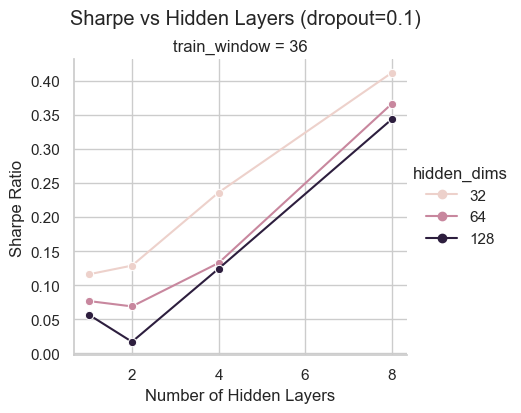

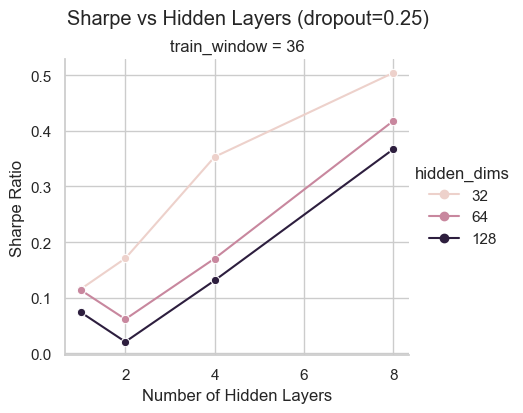

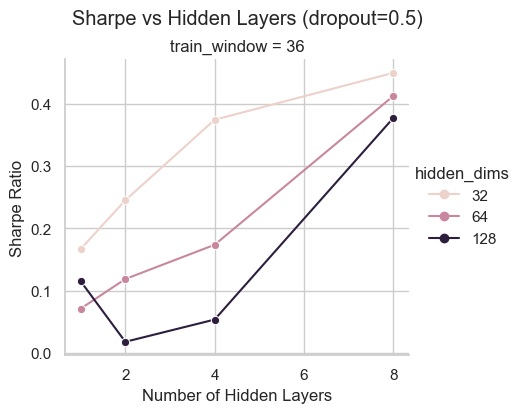

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

df = pd.read_csv("Final_LSTM_results.csv").copy()

# normalize names
df = df.rename(columns={
    "hidden_size": "hidden_dims",
    "num_layers": "n_hidden_layers",
})

# detect sharpe column
if "SR" in df.columns: metric = "SR"
elif "Sharpe" in df.columns: metric = "Sharpe"
elif "sharpe" in df.columns: metric = "sharpe"
elif "sharpe_ratio" in df.columns: metric = "sharpe_ratio"
else: raise ValueError(f"No Sharpe column found. Columns: {list(df.columns)}")

# numeric + dropna
for c in ["train_window", "hidden_dims", "n_hidden_layers", "dropout", metric]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["train_window", "hidden_dims", "n_hidden_layers", "dropout", metric]).copy()

# plot each dropout separately (0.1, 0.25, 0.5)
for d in [0.1, 0.25, 0.5]:
    dfd = df[df["dropout"] == d].copy()

    # critical: sort so line segments connect correctly
    dfd = dfd.sort_values(["train_window", "hidden_dims", "n_hidden_layers"])
    dfd = dfd[dfd['train_window'] == 36] #take only 36 months lookback
    g = sns.relplot(
        data=dfd,
        x="n_hidden_layers",
        y=metric,
        hue="hidden_dims",
        style="hidden_dims",
        col="train_window",
        kind="line",
        marker="o",
        dashes=False,
        estimator=None,         # don't average
        units="hidden_dims",    # connect points per hidden dim
        height=4,
        aspect=1.1,
        facet_kws={"sharey": True, "sharex": True},
    )

    g.set_axis_labels("Number of Hidden Layers", "Sharpe Ratio")
    g.set_titles("train_window = {col_name}")
    g.fig.suptitle(f"Sharpe vs Hidden Layers (dropout={d})", y=1.03)
    plt.show()

### Train window 12 doesnt have much improvements in an case because the seq_len is same as T, lets disregard this in the further analysis

## Vol and Expected return plots

In [38]:
set(df['train_window'])

{12, 36, 60}

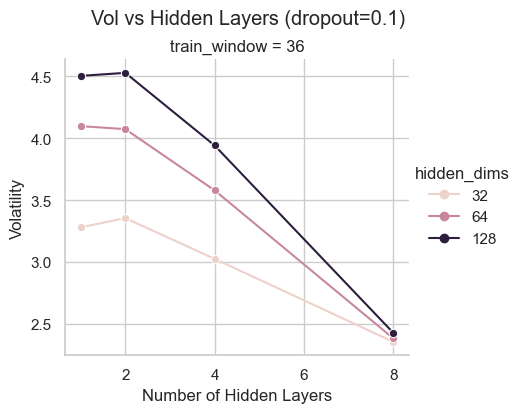

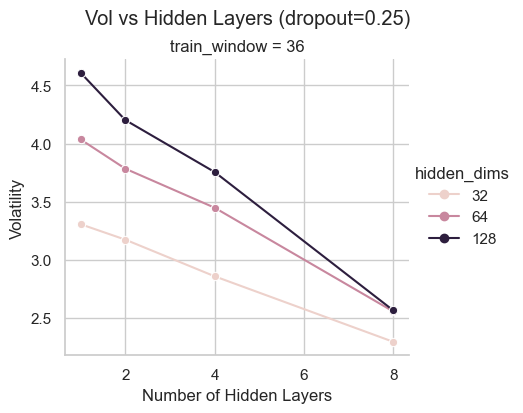

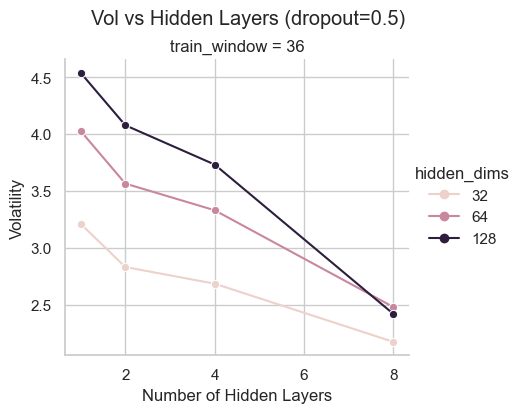

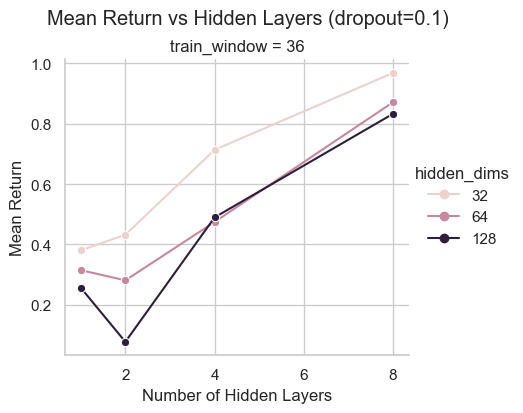

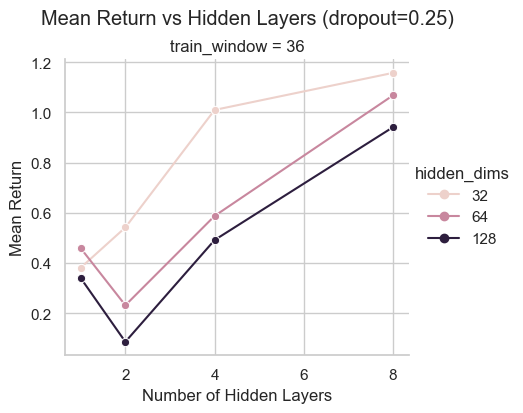

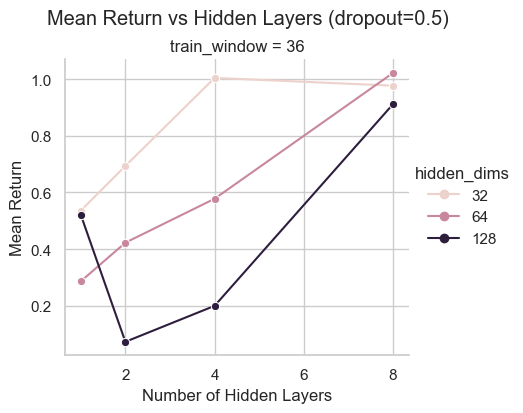

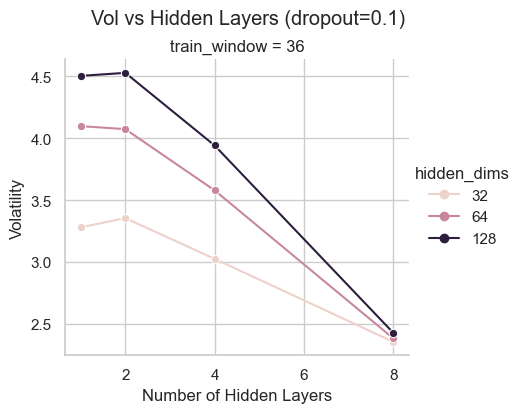

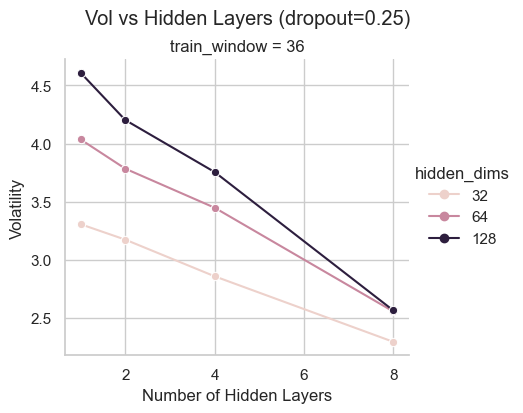

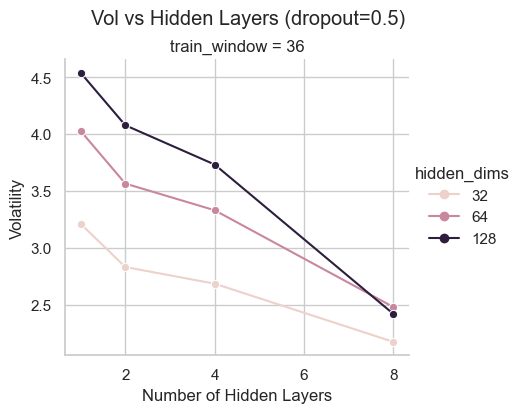

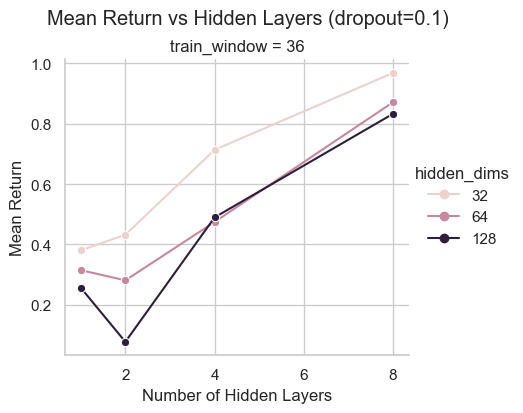

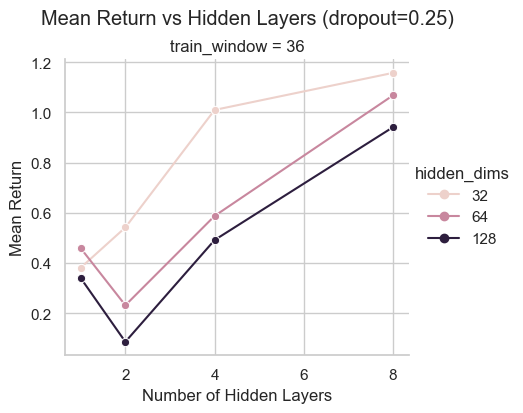

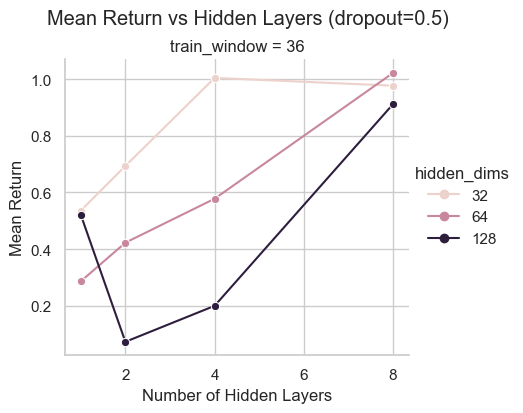

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

df = pd.read_csv("Final_LSTM_results.csv").copy()

# ----------------------------
# Normalize column names
# ----------------------------
df = df.rename(columns={
    "hidden_size": "hidden_dims",
    "num_layers": "n_hidden_layers",
})
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

df = pd.read_csv("Final_LSTM_results.csv").copy()

df = df.rename(columns={
    "hidden_size": "hidden_dims",
    "num_layers": "n_hidden_layers",
})

vol = "Volatility"
mean_col = "Expected Return"

for c in [
    "train_window",
    "hidden_dims",
    "n_hidden_layers",
    "dropout",
    vol,
    mean_col,
]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=[
    "train_window",
    "hidden_dims",
    "n_hidden_layers",
    "dropout",
    vol,
    mean_col,
]).copy()

for d in [0.1, 0.25, 0.5]:

    dfd = df[df["dropout"] == d].copy()
    dfd = dfd.sort_values(["train_window", "hidden_dims", "n_hidden_layers"])
    dfd = dfd[dfd['train_window'] == 36] #take only 36 months lookback

    g = sns.relplot(
        data=dfd,
        x="n_hidden_layers",
        y=vol,
        hue="hidden_dims",
        style="hidden_dims",
        col="train_window",
        kind="line",
        marker="o",
        dashes=False,
        estimator=None,
        units="hidden_dims",
        height=4,
        aspect=1.1,
        facet_kws={"sharey": True, "sharex": True},
    )

    g.set_axis_labels("Number of Hidden Layers", "Volatility")
    g.set_titles("train_window = {col_name}")
    g.fig.suptitle(f"Vol vs Hidden Layers (dropout={d})", y=1.03)

    plt.show()


for d in [0.1, 0.25, 0.5]:

    dfd = df[df["dropout"] == d].copy()
    dfd = dfd.sort_values(["train_window", "hidden_dims", "n_hidden_layers"])
    dfd = dfd[dfd['train_window'] == 36] #take only 36 months lookback

    g = sns.relplot(
        data=dfd,
        x="n_hidden_layers",
        y=mean_col,
        hue="hidden_dims",
        style="hidden_dims",
        col="train_window",
        kind="line",
        marker="o",
        dashes=False,
        estimator=None,
        units="hidden_dims",
        height=4,
        aspect=1.1,
        facet_kws={"sharey": True, "sharex": True},
    )

    g.set_axis_labels("Number of Hidden Layers", "Mean Return")
    g.set_titles("train_window = {col_name}")
    g.fig.suptitle(f"Mean Return vs Hidden Layers (dropout={d})", y=1.03)

    plt.show()

for c in [
    "train_window",
    "hidden_dims",
    "n_hidden_layers",
    "dropout",
    vol,
    mean_col,
]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=[
    "train_window",
    "hidden_dims",
    "n_hidden_layers",
    "dropout",
    vol,
    mean_col,
]).copy()

for d in [0.1, 0.25, 0.5]:

    dfd = df[df["dropout"] == d].copy()
    dfd = dfd.sort_values(["train_window", "hidden_dims", "n_hidden_layers"])
    dfd = dfd[dfd['train_window'] == 36] #take only 36 months lookback

    g = sns.relplot(
        data=dfd,
        x="n_hidden_layers",
        y=vol,
        hue="hidden_dims",
        style="hidden_dims",
        col="train_window",
        kind="line",
        marker="o",
        dashes=False,
        estimator=None,
        units="hidden_dims",
        height=4,
        aspect=1.1,
        facet_kws={"sharey": True, "sharex": True},
    )

    g.set_axis_labels("Number of Hidden Layers", "Volatility")
    g.set_titles("train_window = {col_name}")
    g.fig.suptitle(f"Vol vs Hidden Layers (dropout={d})", y=1.03)

    plt.show()


for d in [0.1, 0.25, 0.5]:

    dfd = df[df["dropout"] == d].copy()
    dfd = dfd.sort_values(["train_window", "hidden_dims", "n_hidden_layers"])
    dfd = dfd[dfd['train_window'] == 36] #take only 36 months lookback

    g = sns.relplot(
        data=dfd,
        x="n_hidden_layers",
        y=mean_col,
        hue="hidden_dims",
        style="hidden_dims",
        col="train_window",
        kind="line",
        marker="o",
        dashes=False,
        estimator=None,
        units="hidden_dims",
        height=4,
        aspect=1.1,
        facet_kws={"sharey": True, "sharex": True},
    )

    g.set_axis_labels("Number of Hidden Layers", "Mean Return")
    g.set_titles("train_window = {col_name}")
    g.fig.suptitle(f"Mean Return vs Hidden Layers (dropout={d})", y=1.03)

    plt.show()

## Observations

### Volatility seems to decrease with strcutural complexity(hidden layers), which aligns with our implicit regularization with over parametrization
### While the sharpe seems to increase with complexity(num Hidden layers), it decrease with hidden_dimensions, why is that? We can attribute this to  
### explosion in hidden vector dimensions, which increases portfolio vol
### Complexity here is a virtue due to structural depth(hidden layer count), but not just due to projecting onto higher dimensions

## Further strengths
### Gradient descent in deeper nets picks lower beta norm solutions

### More sequence length can be cross validated for further performance optmization but our shape with complexity increasing, which aligns with our expectations

## Link to Geometry

### Increase in performance with hidden layers could be thought of structural complexity, one that actually helps in increasing dimensions of return span space in a stable manner
### Conversely, with just hidden dimensions(num dim of vector space in neurons) doesnt actually help achieving above hence the decrease in performance

## TODO: Analyse the geometry better, add more metrics in the backtestLSTM like weight concentration, effective complexity, beta spread, effective rank of F



# ____________________________GAP__________________________